# One day on the shelf

**Blog angle:** *What happens to blueberries on the shelf in one day?*

This notebook is a **MOD-12 microcosm** — we walk through a single store day using the same
constitutive kernels the simulator uses, but in plain Python so each step is visible. No filter,
no policy, no VOI — just inventory aging, shopper demand, who gets picked, and who spoils overnight.

## Setup

From the repo root:

```bash
uv sync --extra notebooks
uv run jupyter lab
```

Then open this notebook and run all cells.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

import blueberries_voi
from blueberries_voi.model.constitutive import (
    allocate_sales,
    death_prob_hazard_product,
    death_prob_survival_ratio,
    picking_weights,
    q10_age_increment,
    weibull_survival,
)
from blueberries_voi.model.params import Cohort, ModelParams
from blueberries_voi.rng import STREAM_ALLOC, STREAM_SPOIL, spawn_rng

print(f"blueberries_voi {getattr(blueberries_voi, '__version__', 'dev')}")

ROOT_SEED = 42
RUN_ID = "blog-one-day"
DAY = 0

rng_alloc = spawn_rng(ROOT_SEED, run_id=RUN_ID, day=DAY, stream=STREAM_ALLOC)
rng_spoil = spawn_rng(ROOT_SEED, run_id=RUN_ID, day=DAY, stream=STREAM_SPOIL)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

blueberries_voi 0.1.0


## Interim M1 defaults

We use the shared `ModelParams` dataclass. Effective age τ advances in **calendar days**
scaled by a Q₁₀ temperature factor (4 °C display case vs 0 °C reference). Spoilage follows a
Weibull survival curve with scale η (days at reference temperature) and shape β.

**Honesty (MOD-22):** β is **unverified** for blueberry *marketability* spoilage — no published
Weibull shape turned up in the literature review. We fix β = 2 for this walkthrough and sweep
β ∈ {1, 2, 4} in the survival plots below. η and Q₁₀ are better anchored; shape is a sensitivity
axis, not a calibrated claim.

In [2]:
params = ModelParams(
    beta=2.0,
    eta_ref=14.0,
    q10=3.0,
    t_ref_c=0.0,
    t_store_c=4.0,
    sigma=0.5,
    demand_mu=30.0,
    uniform_picking=False,
)

dtau = q10_age_increment(
    1.0,
    t_store_c=params.t_store_c,
    t_ref_c=params.t_ref_c,
    q10=params.q10,
)
print(f"One calendar day at {params.t_store_c}°C advances effective age by {dtau:.3f} days")

One calendar day at 4.0°C advances effective age by 1.552 days


## Weibull survival: how frailty grows with age

Survival is $S(\tau) = \exp\!\left(-(\tau/\eta)^\beta\right)$.

- **β = 1** — constant hazard (memoryless); every day feels equally risky.
- **β > 1** — hazard rises with age; old lots become fragile.
- **β = 4** — sharp late-life cliff; small timing errors matter a lot.

The headline VOI sweep uses β ∈ [1, 4]. Here we plot three representative shapes.

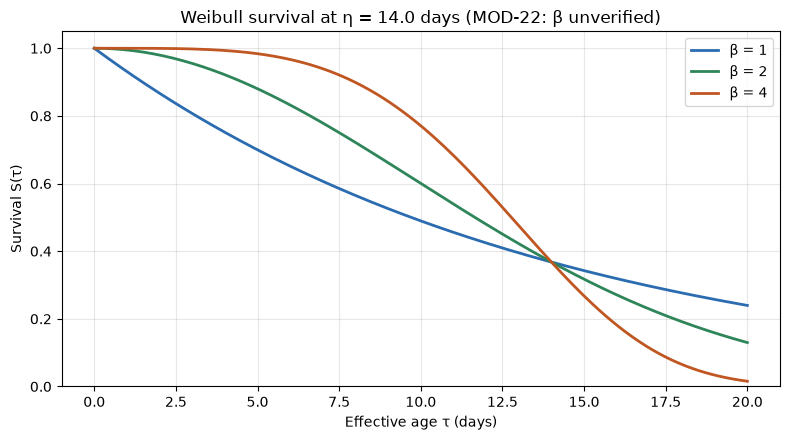

In [3]:
tau_grid = np.linspace(0.0, 20.0, 200)
eta = params.eta_ref
betas = [1, 2, 4]
colors = ["#2b6cb0", "#2f855a", "#c05621"]

fig, ax = plt.subplots()
for beta, color in zip(betas, colors, strict=True):
    surv = [weibull_survival(float(t), beta=beta, eta=eta) for t in tau_grid]
    ax.plot(tau_grid, surv, label=f"β = {beta}", color=color, lw=2)

ax.set_xlabel("Effective age τ (days)")
ax.set_ylabel("Survival S(τ)")
ax.set_title(f"Weibull survival at η = {eta} days (MOD-22: β unverified)")
ax.legend()
ax.set_ylim(0, 1.05)
fig.tight_layout()

## Spoilage law: survival ratio, not hazard × Δt

The one-day death probability must be written as a **conditional survival ratio** (MOD-04):

$$
p_{\text{die}}(\tau) = 1 - \frac{S(\tau + \Delta\tau)}{S(\tau)}
$$

Never as $h(\tau)\,\Delta\tau$. That first-order shortcut drifts with β — exactly the axis we
sweep — and would manufacture or erase the headline effect. At β = 4 the gap is visible.

Absolute gap (ratio − hazard):
  τ= 2.0: +0.0024
  τ= 6.0: +0.0148
  τ=10.0: +0.0223
  τ=14.0: -0.0363


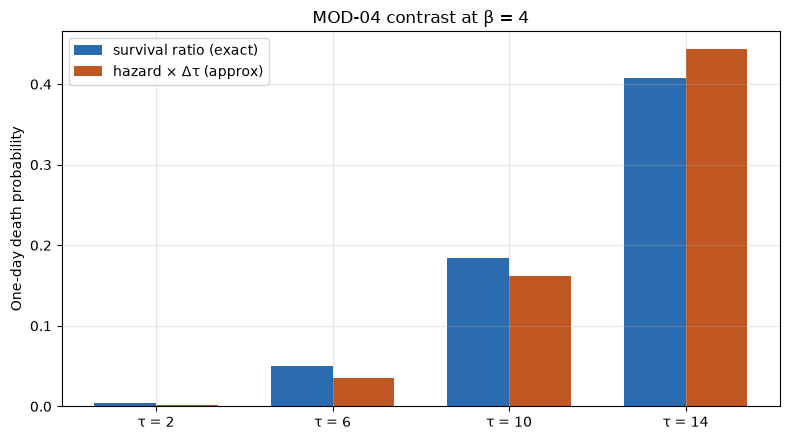

In [4]:
beta_contrast = 4.0
tau_examples = np.array([2.0, 6.0, 10.0, 14.0])

p_ratio = [
    death_prob_survival_ratio(float(t), dtau, beta=beta_contrast, eta=eta)
    for t in tau_examples
]
p_hazard = [
    death_prob_hazard_product(float(t), dtau, beta=beta_contrast, eta=eta)
    for t in tau_examples
]

fig, ax = plt.subplots()
x = np.arange(len(tau_examples))
width = 0.35
ax.bar(x - width / 2, p_ratio, width, label="survival ratio (exact)", color="#2b6cb0")
ax.bar(x + width / 2, p_hazard, width, label="hazard × Δτ (approx)", color="#c05621")
ax.set_xticks(x)
ax.set_xticklabels([f"τ = {t:.0f}" for t in tau_examples])
ax.set_ylabel("One-day death probability")
ax.set_title(f"MOD-04 contrast at β = {beta_contrast:.0f}")
ax.legend()
fig.tight_layout()

print("Absolute gap (ratio − hazard):")
for t, pr, ph in zip(tau_examples, p_ratio, p_hazard, strict=True):
    print(f"  τ={t:4.1f}: {pr - ph:+.4f}")

## MOD-12: within-day order of operations

The daily recursion has a fixed order (ADR 0034 / MOD-12):

1. **Age** — every live cohort advances τ by Δτ (Q₁₀-scaled).
2. **Demand** — shoppers want *D* units (negative binomial in production; fixed here for clarity).
3. **Allocate sales** — pick *min(D, on-hand)* without replacement, weighted by $S(\tau)^{1/\sigma}$.
4. **Spoilage** — Binomial draws on **survivors of step 3**, using the survival ratio at post-age τ.
5. **Deliver** — today's truck arrives **after** sales and spoilage; it is **not** on today's shelf.

Order matters at high β: selling before spoiling (vs the reverse) shifts waste and service level.
Simulator and filter must agree — we show the chosen order explicitly.

## Three cohorts, one morning

Picture a Tuesday morning display with three lots at different effective ages — a fresh delivery
from yesterday, a mid-week lot, and an older back-row tray. Counts are in **pints** (arbitrary
units); only relative magnitudes matter for the story.

In [5]:
cohorts_start = [
    Cohort(n=24, tau=2.0, lot_id=101),
    Cohort(n=18, tau=6.0, lot_id=102),
    Cohort(n=12, tau=10.0, lot_id=103),
]
demand = 28  # fixed for a readable walkthrough; production draws NB(demand_mu, demand_vm)
delivery = Cohort(n=16, tau=0.5, lot_id=201)  # truck arrives after close

labels = [f"lot {c.lot_id}\nτ={c.tau:.1f}" for c in cohorts_start]
counts_before = np.array([c.n for c in cohorts_start], dtype=int)
on_hand_before = int(counts_before.sum())

print("Morning inventory")
for c in cohorts_start:
    s = weibull_survival(c.tau, beta=params.beta, eta=params.eta_ref)
    print(f"  lot {c.lot_id}: n={c.n:3d}, τ={c.tau:4.1f}, S(τ)={s:.3f}")
print(f"  total on hand: {on_hand_before}")
print(f"  shopper demand (fixed): {demand}")

Morning inventory
  lot 101: n= 24, τ= 2.0, S(τ)=0.980
  lot 102: n= 18, τ= 6.0, S(τ)=0.832
  lot 103: n= 12, τ=10.0, S(τ)=0.600
  total on hand: 54
  shopper demand (fixed): 28


### Step 1 — Age

Overnight at 4 °C, every lot gains the same calendar-scaled effective age.

In [6]:
cohorts_aged = [Cohort(n=c.n, tau=c.tau + dtau, lot_id=c.lot_id) for c in cohorts_start]

print(f"Δτ = {dtau:.3f} effective days")
for before, after in zip(cohorts_start, cohorts_aged, strict=True):
    print(f"  lot {before.lot_id}: τ {before.tau:.2f} → {after.tau:.2f}")

Δτ = 1.552 effective days
  lot 101: τ 2.00 → 3.55
  lot 102: τ 6.00 → 7.55
  lot 103: τ 10.00 → 11.55


### Step 2 — Picking weights

Shoppers (and produce clerks restocking from the front) prefer fresher-looking fruit.
Weights are proportional to $S(\tau)^{1/\sigma}$ with σ = 0.5 → stronger fresh bias.

  lot 101: weight=0.519
  lot 102: weight=0.330
  lot 103: weight=0.151


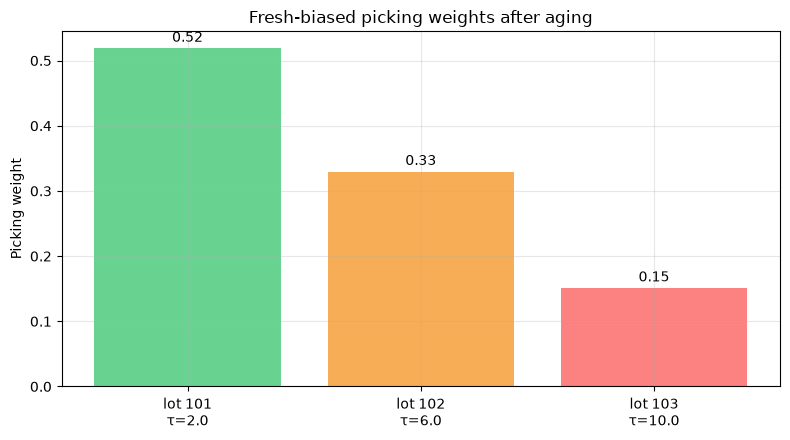

In [7]:
taus_aged = [c.tau for c in cohorts_aged]
weights = picking_weights(
    taus_aged,
    sigma=params.sigma,
    beta=params.beta,
    eta=params.eta_ref,
    uniform=params.uniform_picking,
)

fig, ax = plt.subplots()
bars = ax.bar(labels, weights, color=["#68d391", "#f6ad55", "#fc8181"])
ax.set_ylabel("Picking weight")
ax.set_title("Fresh-biased picking weights after aging")
for bar, w in zip(bars, weights, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{w:.2f}", ha="center")
fig.tight_layout()

for c, w in zip(cohorts_aged, weights, strict=True):
    print(f"  lot {c.lot_id}: weight={w:.3f}")

### Step 3 — Allocate sales

We sell `min(demand, on_hand)` units, drawing cohorts **without replacement** proportional to
the picking weights (Wallenius-style sequential allocation).

In [8]:
counts_aged = [c.n for c in cohorts_aged]
sales = allocate_sales(counts_aged, demand, weights, rng_alloc)
sales_total = int(sales.sum())
lost_sales = max(0, demand - on_hand_before)

cohorts_post_sales = [
    Cohort(n=c.n - int(s), tau=c.tau, lot_id=c.lot_id)
    for c, s in zip(cohorts_aged, sales, strict=True)
]

print(f"Sold {sales_total} of {demand} demanded ({lost_sales} lost if demand > on-hand)")
for c, s in zip(cohorts_aged, sales, strict=True):
    print(f"  lot {c.lot_id}: sold {int(s):2d}, remaining {c.n - int(s):2d}")

Sold 28 of 28 demanded (0 lost if demand > on-hand)
  lot 101: sold 11, remaining 13
  lot 102: sold  9, remaining  9
  lot 103: sold  8, remaining  4


### Step 4 — Spoilage on survivors

Each remaining unit independently spoils with probability given by the **survival ratio** at its
post-age τ. Population-level waste is Binomial(*n*, *p*), not *n·p* — variance matters when lots
are small.

In [9]:
waste = np.zeros(len(cohorts_post_sales), dtype=int)
cohorts_post_spoil: list[Cohort] = []

for i, c in enumerate(cohorts_post_sales):
    if c.n <= 0:
        cohorts_post_spoil.append(c)
        continue
    p_die = death_prob_survival_ratio(
        c.tau, dtau, beta=params.beta, eta=params.eta_ref
    )
    p_die = float(np.clip(p_die, 0.0, 1.0))
    w = int(rng_spoil.binomial(c.n, p_die))
    waste[i] = w
    cohorts_post_spoil.append(Cohort(n=c.n - w, tau=c.tau, lot_id=c.lot_id))

waste_total = int(waste.sum())
cohorts_post_spoil = [c for c in cohorts_post_spoil if c.n > 0]

print(f"Waste total: {waste_total}")
for c, w, s in zip(cohorts_post_sales, waste, sales, strict=True):
    p_die = death_prob_survival_ratio(c.tau, dtau, beta=params.beta, eta=params.eta_ref)
    print(
        f"  lot {c.lot_id}: n={c.n:2d}, p_die={p_die:.4f}, waste={int(w):2d}, "
        f"survivors={c.n - int(w):2d}"
    )

Waste total: 5
  lot 101: n=13, p_die=0.0662, waste= 1, survivors=12
  lot 102: n= 9, p_die=0.1235, waste= 2, survivors= 7
  lot 103: n= 4, p_die=0.1773, waste= 2, survivors= 2


### Step 5 — Delivery (after sales and spoilage)

The overnight truck is **not** available to today's shoppers. It lands on the shelf only after
we have already sold and spoiled what was there this morning.

In [10]:
cohorts_end = cohorts_post_spoil + [delivery]
on_hand_end = sum(c.n for c in cohorts_end)

print("Closing inventory (includes delivery)")
for c in cohorts_end:
    tag = " ← delivered tonight" if c.lot_id == delivery.lot_id else ""
    print(f"  lot {c.lot_id}: n={c.n:3d}, τ={c.tau:4.1f}{tag}")
print(f"  total on hand: {on_hand_end}")
print()
print("Day ledger")
print(f"  started:  {on_hand_before}")
print(f"  sold:     {sales_total}")
print(f"  wasted:   {waste_total}")
print(f"  delivered:{delivery.n}")
print(f"  closing:  {on_hand_end}")

Closing inventory (includes delivery)
  lot 101: n= 12, τ= 3.6
  lot 102: n=  7, τ= 7.6
  lot 103: n=  2, τ=11.6
  lot 201: n= 16, τ= 0.5 ← delivered tonight
  total on hand: 37

Day ledger
  started:  54
  sold:     28
  wasted:   5
  delivered:16
  closing:  37


## Inventory before and after

Side-by-side counts for the three morning lots. Delivery is shown separately — it was not on the
shelf when demand arrived.

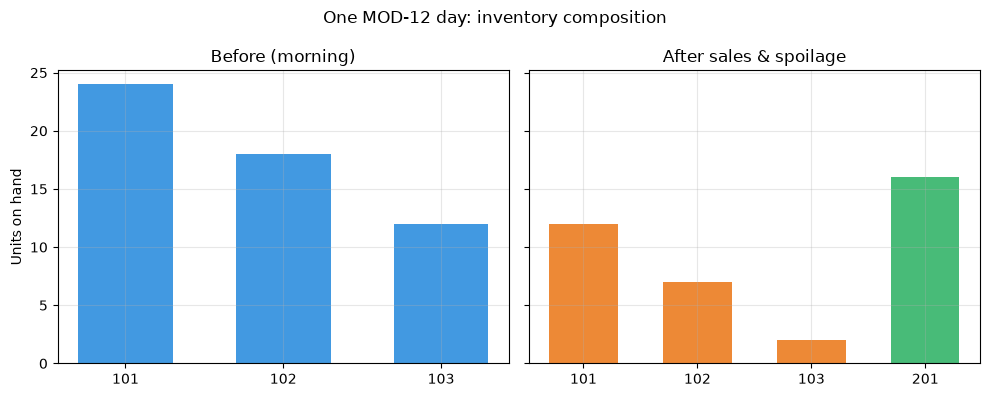

In [11]:
lot_ids = [c.lot_id for c in cohorts_start]
counts_after_morning = np.array(
    [next(c.n for c in cohorts_post_spoil if c.lot_id == lid) for lid in lot_ids],
    dtype=int,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
x = np.arange(len(lot_ids))
width = 0.6

axes[0].bar(x, counts_before, width, color="#4299e1", label="start of day")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(i) for i in lot_ids])
axes[0].set_ylabel("Units on hand")
axes[0].set_title("Before (morning)")

axes[1].bar(x, counts_after_morning, width, color="#ed8936", label="after sales + spoil")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(i) for i in lot_ids])
axes[1].set_title("After sales & spoilage")

axes[1].bar(
    len(lot_ids),
    delivery.n,
    width,
    color="#48bb78",
    label="delivery (not in sales)",
)
axes[1].set_xticks(list(x) + [len(lot_ids)])
axes[1].set_xticklabels([str(i) for i in lot_ids] + [str(delivery.lot_id)])

fig.suptitle("One MOD-12 day: inventory composition")
fig.tight_layout()

## Takeaways

1. **Aging is deterministic** — every lot gains the same Δτ overnight; fragility differences come
   from where each lot started on the survival curve.
2. **Picking weights steer sales** toward fresher lots; the oldest tray may sit while younger stock
   sells — then spoil.
3. **Spoilage uses the survival ratio**, not hazard × Δt; at β = 4 the shortcut lies.
4. **MOD-12 order** — deliver *after* sales and spoil — means tonight's truck cannot rescue today's
   service level.
5. **β is a sweep parameter (MOD-22)**, not a literature-calibrated blueberry fact. Treat the
   absolute waste numbers as illustrative; the *shape* of the sensitivity is the point.

Next notebooks can wire this day kernel into multi-day paths, connect demand stochasticity, and
contrast policies — but every extension should keep importing these same constitutive functions.